In [6]:
import numpy as np
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

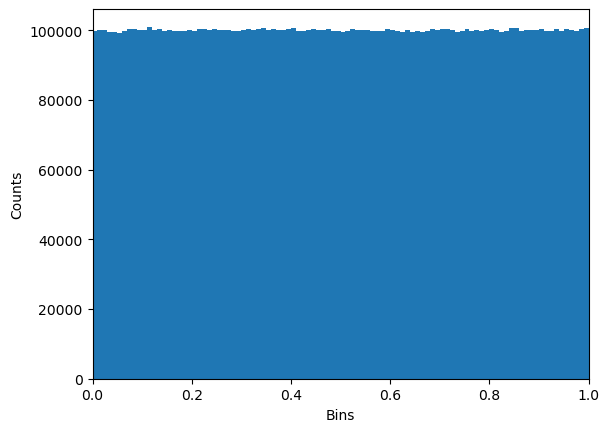

In [7]:
# Modelling Exercise 1a

rng = np.random.default_rng()

N = 10**7  # amount of random numbers
random_list = rng.random(N)

standard_deviation =np.std(random_list)

# print(random_list)
plt.hist(random_list,100)
plt.xlabel('Bins')
plt.ylabel('Counts')
plt.xlim(0,1)
plt.show

C:\Users\yagoh\AppData\Local\Temp\ipykernel_20160\3174700267.py:18: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(left=0)


(0.0, 0.33911601866693386)

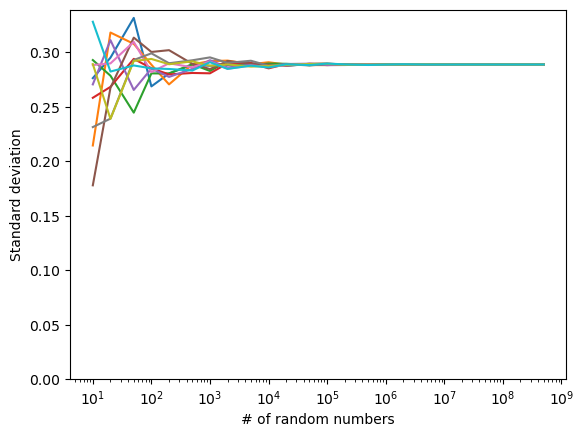

In [8]:
j=0
while j<10:
    N_range = [10, 2*10, 5*10, 10**2, 2*10**2, 5*10**2, 10**3, 2*10**3, 5*10**3, 10**4, 2*10**4, 5*10**4, 10**5, 2*10**5, 5*10**5, 10**6, 2*10**6, 5*10**6, 10**7, 2*10**7, 5*10**7, 10**8, 2*10**8, 5*10**8]
    std_list = np.zeros(len(N_range))
    for i in range(len(N_range)):
        rng = np.random.default_rng()
        n = N_range[i]
        random_list = rng.random(n)
        std_list[i] = np.std(random_list)
        # print(f'Standard deviation of {n} random numbers is equal to {std_list[i]}.')

    stdplot = plt.semilogx(N_range, std_list)
    
    j+=1

plt.xlabel('# of random numbers')
plt.ylabel('Standard deviation')
plt.xlim(left=0)
plt.ylim(bottom=0)

In [9]:
# Modelling Exercise 1b

# Central limit theorem
N = 10**7
m = 20

rng = np.random.default_rng()

xi = np.zeros(N)

for _ in range(m):
    xi += np.sqrt(12/m)*(rng.random(N)-0.5)
    # Scaling with square root of 2, shifting by 3/m for m=6. 
    # By varying m, it is found that the shift should be fixed at 0.5.
    # By varying m, it is also found that the scaling should be sqrt(m/12)

mean = np.mean(xi)
std = np.std(xi)

print(f'standard deviation = {std:.3f}, mean = {mean:.3f}.')

set1 = xi

standard deviation = 1.000, mean = -0.000.


In [14]:
# Box-Muller method

set2 = np.zeros(N)
n_pairs = N//2

xi1 = rng.random(n_pairs)
xi2 = rng.random(n_pairs)

xi_new1 = np.sqrt((-2*np.log(xi1)))*(np.cos(2*np.pi*xi2))
xi_new2 = np.sqrt((-2*np.log(xi1)))*(np.sin(2*np.pi*xi2))

set2[0::2] = xi_new1
set2[1::2] = xi_new2


In [15]:
# Built-in normally distributed random number generator
N = 10**7
set3 = rng.standard_normal((N, 1)).flatten()

Central limit: RMSE = 1.291121e-03


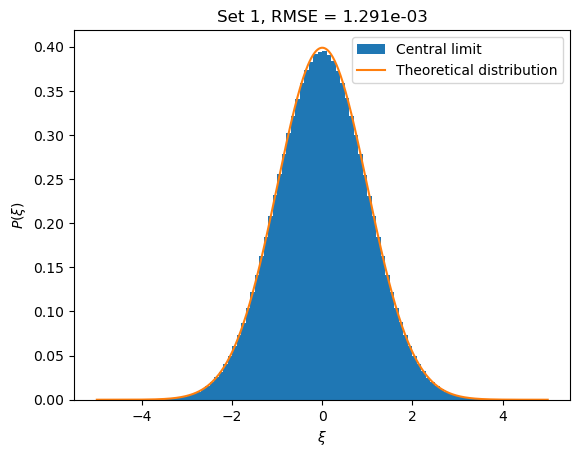

Box-Muller: RMSE = 3.146780e-04


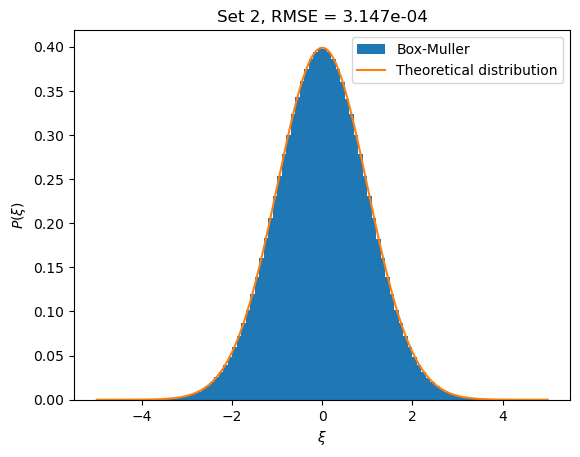

Numpy: RMSE = 2.595923e-04


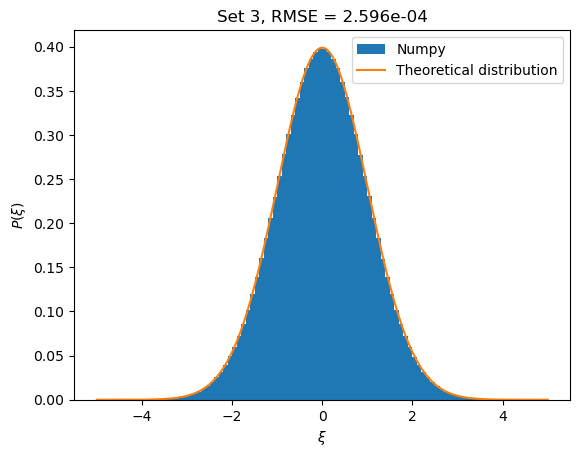

In [16]:
# Analysis of the three sets

sets = [set1, set2, set3]
labels = ['Central limit', 'Box-Muller', 'Numpy']
titles = ['Set 1', 'Set 2', 'Set 3']

x = np.linspace(-5, 5, 1000)
P = 1/np.sqrt(2*np.pi) * np.exp(-x**2/2)

for data, label, title in zip(sets, labels, titles):
    plt.figure()

    # Histogram data used for RMSE
    hist, bin_edges = np.histogram(data,bins=100,range=(-5, 5),density=True)

    # Position of the centre of every histogram bin
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Theoretical Gaussian evaluated at those same positions
    P_analytical = (1/np.sqrt(2*np.pi)*np.exp(-bin_centers**2/2))

    # Root Mean Square Error
    rmse = np.sqrt(np.mean((hist - P_analytical)**2))

    print(f'{label}: RMSE = {rmse:.6e}')

    # Plot numerical distribution
    plt.hist(data,bins=100,range=(-5, 5),density=True,label=label)

    # Plot theoretical distribution
    plt.plot(x,P,label="Theoretical distribution")

    plt.xlabel(r"$\xi$")
    plt.ylabel(r"$P(\xi)$")
    plt.legend()
    plt.title(f'{title}, RMSE = {rmse:.3e}')

    plt.show()

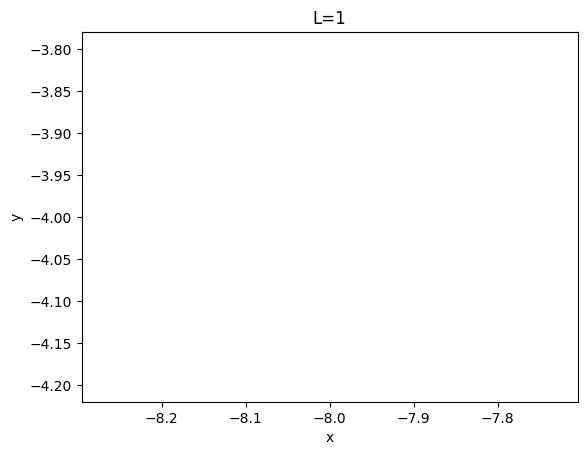

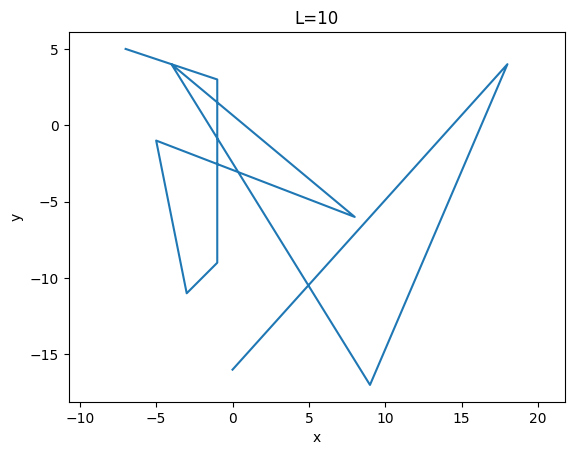

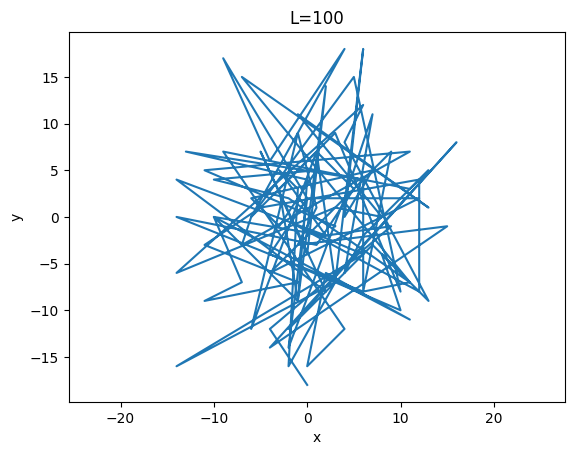

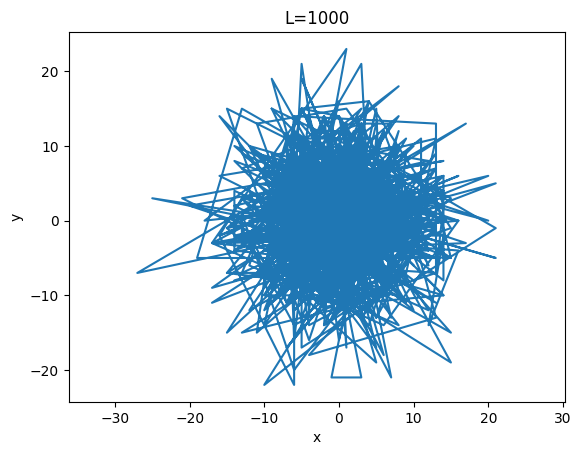

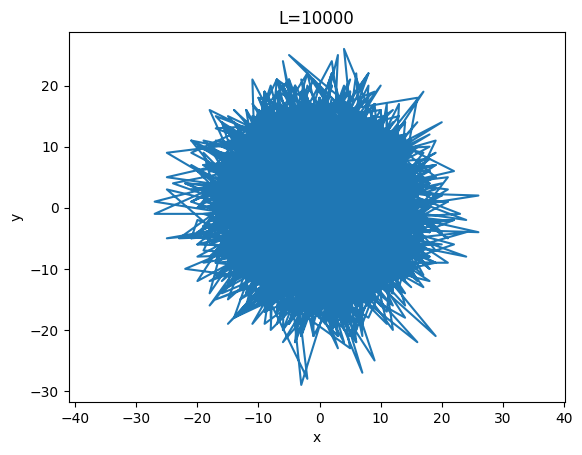

In [170]:
# Modelling Exercise 1c

rng = np.random.default_rng()

L_values = [1, 10, 100, 1000, 10000]
titles = ['L=1', 'L=10', 'L=100', 'L=1000', 'L=10000']

r = 1           # step length
x, y = (0, 0)   # initial position

N = 100         # number of steps in a random walk
L = 10

for L, title in zip(L_values, titles):
    total_steps = N*L
    x, y = (0,0)
    X, Y = (np.zeros(L), np.zeros(L))
    for walk in range(L):
        steps = rng.integers(0,4, size=(N))
        steps_pos_x = sum(steps==0)
        steps_neg_x = sum(steps==1)
        steps_pos_y = sum(steps==2)
        steps_neg_y = sum(steps==3)

        X[walk] = x + steps_pos_x - steps_neg_x
        Y[walk] = y + steps_pos_y - steps_neg_y

    plt.plot(X, Y)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.title(title)
    plt.show()
